# Matplotlib基础绘图

学习目标：用 Figure 和 Axes 绘制常用图表，组织输入数据，调整颜色、坐标、标签与图例，并保存成图。

前置知识：Python 模块导入、列表与循环、NumPy 数组索引与按轴计算、均值与标准差。

运行环境：Python 3.12、Matplotlib 3.11、NumPy 2.5；普通 CPU 即可。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

本章数据均为教学模拟，不代表实际设备或实验结论。图形使用 plt.show() 显示；第 2 节设置中文字体，第 13 节把导出文件保存在系统临时目录。

阅读安排：可分三次学习。第 1～4 节完成基本绘图与图形选择；第 5～11 节比较组成、尺度、误差和颜色；第 12～13 节练习样式、图形组合与导出。每种图的用途、数据、绘制与调整说明集中在同一个代码单元中，运行后直接看图。首次运行按单元顺序完成，后续按图形类型回查。

## 1 先画一条温度曲线

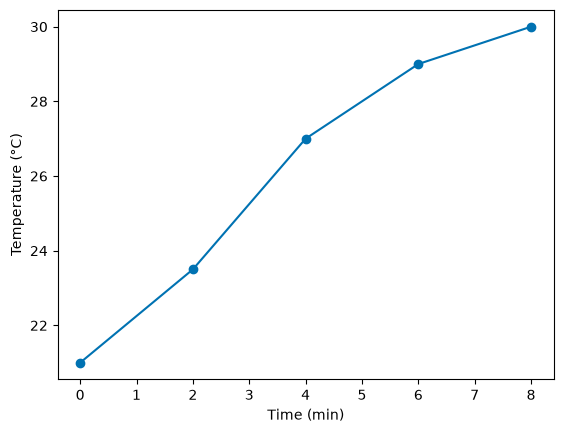

In [1]:
# 适用场景：折线图查看有顺序的观测如何变化；plot 按输入顺序连接，不会自动排序。
# 数据组织：两条等长数组逐项对应，时间单位 min，温度单位 °C；以下是五次模拟读数。
import matplotlib.pyplot as plt
import numpy as np

time = np.array([0, 2, 4, 6, 8])
temperature = np.array([21.0, 23.5, 27.0, 29.0, 30.0])

# 最小绘制：subplots 创建 Figure（整图）和 Axes（绘图区），plot 接收横、纵坐标。
fig, ax = plt.subplots()
# 常用参数调整：marker='o' 标出观测位置，color 设置线条颜色；轴标签补齐含义和单位。
# Time 是时间，Temperature 是温度；中文字体在下一个主题设置。
ax.plot(time, temperature, marker="o", color="#0072B2")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (°C)")
# 实际成图：plt.show() 显示当前图；修改一个温度值再运行，观察相应点和连线如何变化。
plt.show()

## 2 图形对象、中文与标签

### 2.1 Figure、Axes 和 Axis 的区别

在上一张温度图里，fig 与 ax 分别负责什么？把整张图、绘图区、坐标轴对象分开看，再判断要把设置写给谁。

![一个 Figure 中容纳两个 Axes，每个普通二维 Axes 都有横向 xaxis 和纵向 yaxis。](image/illustration/01-01-figure-axes-axis.svg)

这是对象关系示意，点的位置不是温度数据。上一例只有一个 Axes；图中画两个，是为了显示 Figure 可以管理多个绘图区。Axes 虽以 s 结尾，这里仍指一个绘图区，不等同于 Axis。

| 名称 | 中文名称／含义 | 本章用法 |
| --- | --- | --- |
| Figure | 整张图 | fig 管理图幅、布局和导出 |
| Axes | 绘图区 | ax 绘制数据、设置标题和轴标签 |
| Axis | 单条坐标轴对象 | ax.xaxis、ax.yaxis 管理尺度、刻度及刻度文字 |

下面用类型和归属检查把图中的三层对应到上一例对象。后续始终把操作发给明确的 ax，多个绘图区也能看清数据位置。plt.close(fig) 关闭该图并释放 pyplot 对它的管理；已保存的 Notebook 图片输出仍可阅读。

In [2]:
# 沿用上一单元的 fig 和 ax；这里只观察对象关系，不重新作图。
print(type(fig).__name__, type(ax).__name__)  # 预期：Figure Axes
print(type(ax.xaxis).__name__, type(ax.yaxis).__name__)  # 预期：XAxis YAxis
print(ax.figure is fig)  # 预期：True；这个绘图区属于这张图。
plt.close(fig)

Figure Axes
XAxis YAxis
True


### 2.2 中文字体、标题与图例

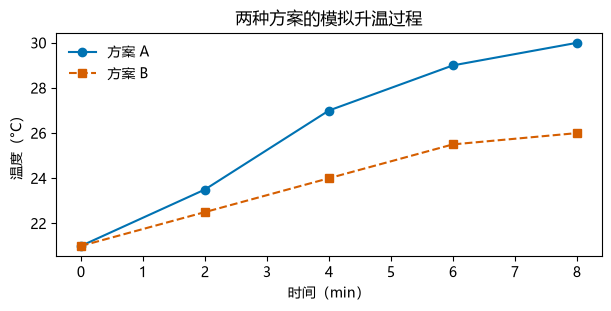

In [3]:
# 适用场景：在同一张折线图中比较两个系列，并添加中文标题与图例。
# 数据组织：复用 time、temperature，再加入同样五个时刻的 temperature_b。
# 中文字体需包含相应字形；其他系统可用 font_manager.get_font_names() 查找本机字体，
# 再替换 font_name，例如本机实际安装的 Noto Sans CJK SC；仍需查看负号和单位字形。
from matplotlib import font_manager

font_name = "Microsoft YaHei"
font_manager.findfont(font_name, fallback_to_default=False)
plt.rcParams["font.family"] = [font_name, "sans-serif"]

temperature_b = np.array([21.0, 22.5, 24.0, 25.5, 26.0])
# 最小绘制：在同一个 ax 上调用两次 plot，两个系列共用时间坐标。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
ax.plot(time, temperature, color="#0072B2", marker="o", label="方案 A")
ax.plot(
    time, temperature_b, color="#D55E00", marker="s", linestyle="--", label="方案 B"
)
# 常用参数调整：figsize 以英寸设置宽、高；constrained 布局为标签留出空间。
# rcParams 设置后续默认字体；label 为系列命名，legend 显示图例。
# 蓝色圆点实线与橙色方点虚线共同区分系列；后续保留同样含义。
ax.set_title("两种方案的模拟升温过程")
ax.set_xlabel("时间（min）")
ax.set_ylabel("温度（°C）")
ax.legend(frameon=False)  # frameon=False 去掉图例边框。
# 实际成图：查看中文、°C 和图例是否完整；尝试改变 marker、linestyle 或图幅。
plt.show()

## 3 子图与统一坐标

(2,)


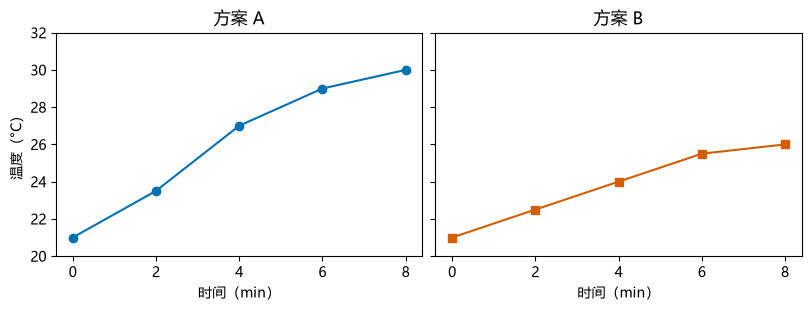

In [4]:
# 适用场景：把两条曲线分别放进子图，保持相同坐标便于比较。
# 数据组织：复用 time、temperature 和 temperature_b，两个系列单位相同。
# subplots(1, 2) 返回含两个 Axes 的一维数组；两个维度都大于 1 时默认返回二维数组，
# 单个绘图区默认返回 Axes；squeeze=False 可以固定为二维结构。
# 最小绘制：创建一行两列，分别向 axes[0] 和 axes[1] 绘图。
fig, axes = plt.subplots(
    1, 2, figsize=(8, 3), sharex=True, sharey=True, layout="constrained"
)
axes[0].plot(time, temperature, marker="o", color="#0072B2")
axes[1].plot(time, temperature_b, marker="s", color="#D55E00")
# 常用参数调整：sharex、sharey 共享相应坐标轴；不同变量或单位不应仅为排版而共享。
# set_ylim 只设显示范围，不删除数据；constrained 布局之后仍需观察标签是否拥挤。
axes[0].set_title("方案 A")
axes[1].set_title("方案 B")
axes[0].set_ylim(20, 32)
axes[0].set_ylabel("温度（°C）")
for ax in axes:
    ax.set_xlabel("时间（min）")
print(axes.shape)  # 预期：(2,)；共享纵轴后，右图默认省略重复刻度文字。
# 实际成图：两图同一高度代表同一温度；试改 figsize，保留坐标范围再比较。
plt.show()

## 4 根据问题选择图形

### 4.1 折线图与散点图

观测数： 8


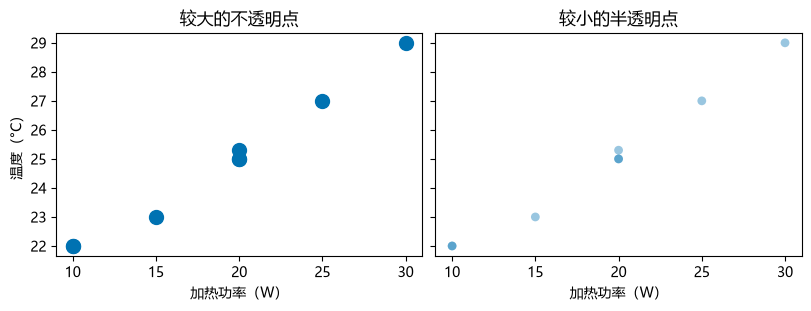

In [5]:
# 适用场景：散点图查看两个变量的关系，每个点是一对观测，不默认连接相邻点。
# 数据组织：power 和 reading 逐项对应同一次模拟测量，单位分别为 W 和 °C。
# 本单元并列观察同一批点的大小和透明度；折线图则适合已有明确顺序的观测。
power = np.array([10, 10, 15, 20, 20, 20, 25, 30])
reading = np.array([22, 22, 23, 25, 25, 25.3, 27, 29])

# 最小绘制：scatter 的前两个输入分别给出横、纵坐标。
fig, axes = plt.subplots(
    1, 2, figsize=(8, 3), sharex=True, sharey=True, layout="constrained"
)
# 常用参数调整：s 是点面积，单位 points²，不是半径；alpha 在 0～1 间控制不透明度。
# 右图缩小 s、降低 alpha，并用 edgecolors='none' 去掉描边。
axes[0].scatter(power, reading, s=100, color="#0072B2")
axes[1].scatter(power, reading, s=40, alpha=0.4, color="#0072B2", edgecolors="none")
axes[0].set_title("较大的不透明点")
axes[1].set_title("较小的半透明点")
axes[0].set_ylabel("温度（°C）")
for ax in axes:
    ax.set_xlabel("加热功率（W）")
print("观测数：", len(power))  # 预期：8；可见点位置少于 8 个，因为存在重合。
# 实际成图：完全重合的点仍无法精确数出；比较两图，再只改 s 或 alpha 观察。
plt.show()

### 4.2 柱状图比较类别

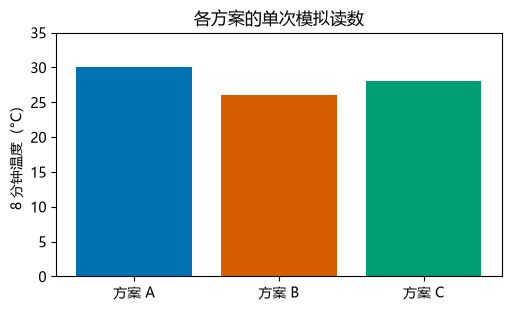

In [6]:
# 适用场景：柱状图比较类别对应的数值；柱高直接使用输入，不自动求和或求均值。
# 数据组织：每个名称对应一个 8 分钟时的单次模拟温度，数值不是重复测量均值。
names = ["方案 A", "方案 B", "方案 C"]
final_temperature = [30.0, 26.0, 28.0]

# 最小绘制：bar(类别, 数值) 为每个类别画一根柱。
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
# 常用参数调整：color 列表逐项设置柱色；set_ylim 保留零基线，使柱长对应数值。
# 要强调较小温差，可考虑点图并写清坐标范围。
ax.bar(names, final_temperature, color=["#0072B2", "#D55E00", "#009E73"])
ax.set_ylim(0, 35)
ax.set_ylabel("8 分钟温度（°C）")
ax.set_title("各方案的单次模拟读数")
# 实际成图：比较三根柱高，再修改一个类别的数值；本图不表示测量波动。
plt.show()

### 4.3 直方图查看分布

[6. 6.] [3. 3. 3. 3.]
12 12


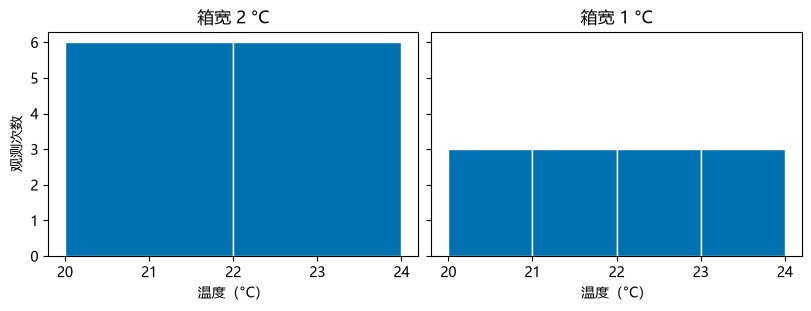

In [7]:
# 适用场景：直方图观察数值分布；横轴是数值区间，与柱状图的类别轴不同。
# 数据组织：samples 的每个元素是一次模拟温度测量，两图使用同样 12 个值。
samples = np.array(
    [20.1, 20.4, 20.8, 21.0, 21.2, 21.4, 22.0, 22.1, 22.5, 23.0, 23.2, 23.6]
)

# 最小绘制：hist(samples) 按区间计数；这里并列比较两种 bins。
fig, axes = plt.subplots(
    1, 2, figsize=(8, 3), sharex=True, sharey=True, layout="constrained"
)
# 常用参数调整：bins 列表给出区间边界；除最后一箱含右端点外，其余箱左闭右开。
# color 设填充，edgecolor='white' 分隔箱体；两图共享范围，只改变箱宽。
# 若改为 density=True，总柱面积为 1（高度乘宽度再求和），不是柱高之和为 1。
wide_counts, wide_edges, _ = axes[0].hist(
    samples, bins=[20, 22, 24], color="#0072B2", edgecolor="white"
)
narrow_counts, narrow_edges, _ = axes[1].hist(
    samples, bins=[20, 21, 22, 23, 24], color="#0072B2", edgecolor="white"
)
axes[0].set_title("箱宽 2 °C")
axes[1].set_title("箱宽 1 °C")
axes[0].set_ylabel("观测次数")
for ax in axes:
    ax.set_xlabel("温度（°C）")
print(wide_counts, narrow_counts)  # 预期：[6. 6.] 和 [3. 3. 3. 3.]。
print(
    int(wide_counts.sum()), int(narrow_counts.sum())
)  # 都是 12，无观测落在边界范围外。
# 实际成图：宽箱合并局部差异，窄箱保留更多起伏；两组计数仍各合计为 12。
plt.show()

## 5 柱状图的排序、分组与堆叠

### 5.1 水平条形图与排序

['报表生成' '模型推理' '数据清洗' '文件归档'] [30 24 18 12]


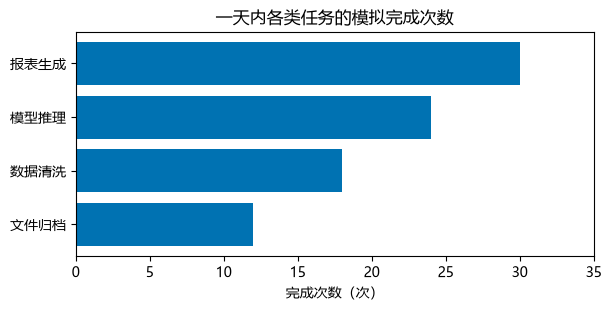

In [8]:
# 适用场景：水平条形图比较类别数值，长类别名可以横向阅读。
# 数据组织：每类任务对应一天内的模拟完成次数；类别和次数必须一起重排。
# argsort 产生升序索引，[::-1] 改为降序；有自然顺序的类别应保留有意义的顺序。
task_names = np.array(["数据清洗", "报表生成", "模型推理", "文件归档"])
task_counts = np.array([18, 30, 24, 12])
task_order = np.argsort(task_counts)[::-1]

# 最小绘制：barh(类别, 数值) 把类别放在纵轴，条长默认从横坐标 0 开始。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
ax.barh(task_names[task_order], task_counts[task_order], color="#0072B2")
# 常用参数调整：set_inverted(True) 把排序后的首项放在上方；set_xlim 设置显示范围。
ax.yaxis.set_inverted(True)
ax.set_xlim(0, 35)
ax.set_xlabel("完成次数（次）")
ax.set_title("一天内各类任务的模拟完成次数")
print(task_names[task_order], task_counts[task_order])
# 从上到下为报表生成 30、模型推理 24、数据清洗 18、文件归档 12。
# 实际成图：最长条应在最上方；试改为升序，同时核对类别与数值仍一一对应。
plt.show()

### 5.2 分组柱状图比较对应类别

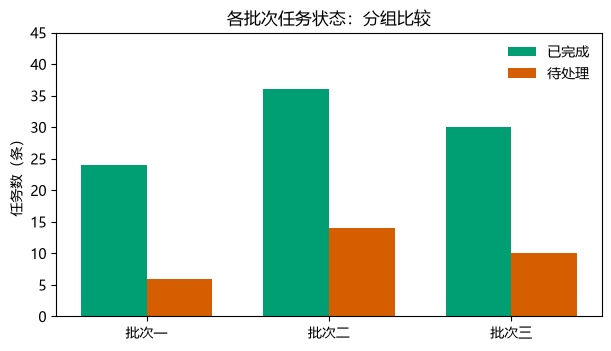

In [9]:
# 适用场景：分组柱状图并排比较同一类别中的多个系列。
# 数据组织：completed、pending 都按三个批次排列，单位为条；positions 给出组中心。
batch_names = ["批次一", "批次二", "批次三"]
completed = np.array([24, 36, 30])
pending = np.array([6, 14, 10])
positions = np.arange(len(batch_names))
width = 0.36

# 最小绘制：分别画两组 bar，让它们位于同一中心的左右两侧。
fig, ax = plt.subplots(figsize=(6, 3.4), layout="constrained")
# 常用参数调整：width 是单柱宽度，左右各偏移 width/2；默认 align='center'。
# set_xticks 的位置与 labels 对应；用颜色和 label、legend 区分状态。
ax.bar(positions - width / 2, completed, width, color="#009E73", label="已完成")
ax.bar(positions + width / 2, pending, width, color="#D55E00", label="待处理")
ax.set_xticks(positions, labels=batch_names)
ax.set_ylim(0, 45)
ax.set_ylabel("任务数（条）")
ax.set_title("各批次任务状态：分组比较")
ax.legend(frameon=False)
# 实际成图：同一批次的两根柱都从 0 起；试调 width，避免柱子互相覆盖。
plt.show()

### 5.3 堆叠柱状图同时显示总量与组成

各批次总数： [30 50 40]


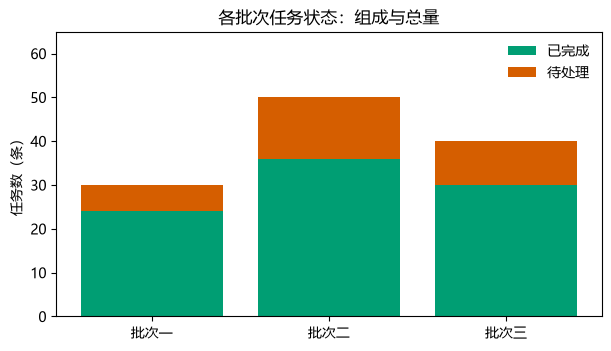

In [10]:
# 适用场景：堆叠柱状图同时表达各类别的总量与组成。
# 数据组织：复用 batch_names、completed、pending；两种状态互不重叠且覆盖全部任务。
# 单位不同或重复计数的类别不能这样相加；比较上层分量时，分组柱的共同零基线更方便。
# 最小绘制：先画下层，再用 bottom 指定上层起点。
fig, ax = plt.subplots(figsize=(6, 3.4), layout="constrained")
ax.bar(batch_names, completed, color="#009E73", label="已完成")
# 常用参数调整：height 仍是该部分自己的数量；bottom=completed，不能把 height 写成总和。
ax.bar(batch_names, pending, bottom=completed, color="#D55E00", label="待处理")
ax.set_ylim(0, 65)
ax.set_ylabel("任务数（条）")
ax.set_title("各批次任务状态：组成与总量")
ax.legend(frameon=False)
print("各批次总数：", completed + pending)  # 预期：[30 50 40]。
# 实际成图：柱顶表示总量，橙色层的厚度才表示待处理数；修改 pending 后再画一次。
plt.show()

## 6 饼图与环形图表达占比

### 6.1 饼图需要一个明确的整体

各类占比： [0.5  0.25 0.15 0.1 ]


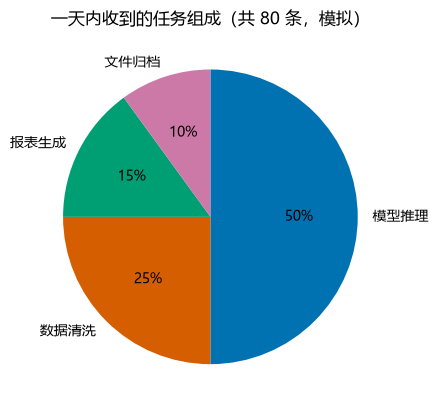

In [11]:
# 适用场景：饼图查看一个整体中少量类别的组成；接近数值的精确比较可改用条形图。
# 数据组织：一天 80 条模拟任务，每条只归入一类，四类完整覆盖整体；输入非负且总和大于 0。
# pie 默认 normalize=True，按各值除以总和分配扇区；漏掉类别仍会归一化为整圆。
# 多选次数会重复计人，不能直接作为人数占比；总数为 0 时没有可解释的占比。
category_names = ["模型推理", "数据清洗", "报表生成", "文件归档"]
category_counts = np.array([40, 20, 12, 8])
category_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# 最小绘制：pie(category_counts) 接收各类次数，不必先换成百分比。
fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
# 常用参数调整：labels 写类别；autopct='%.0f%%' 显示整数百分比，%% 表示百分号。
# startangle=90 从圆顶开始，counterclock=False 按顺时针排列；colors 与类别顺序对应。
# 百分比文字会舍入，不用它反推原始次数。
ax.pie(
    category_counts,
    labels=category_names,
    autopct="%.0f%%",
    startangle=90,
    counterclock=False,
    colors=category_colors,
)
ax.set_title("一天内收到的任务组成（共 80 条，模拟）")
print("各类占比：", category_counts / category_counts.sum())
# 实际成图：四类依次为 50%、25%、15%、10%；试只改 startangle，比例应保持不变。
plt.show()

### 6.2 环形图保留同一套占比

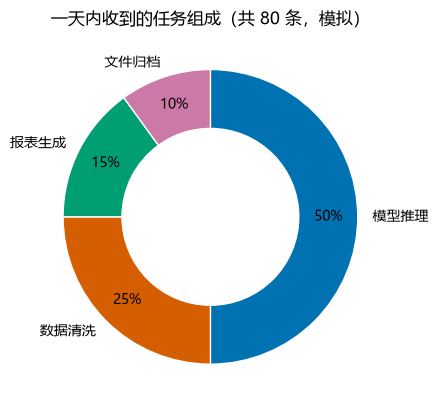

In [12]:
# 适用场景：环形图在饼图中心留白，仍表达同一整体的组成。
# 数据组织：复用 category_counts、category_names、category_colors，比例算法不变。
# 最小绘制：仍调用 pie，通过 wedgeprops 指定扇区宽度。
fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
# 常用参数调整：wedgeprops 的 width=0.4 是径向宽度，默认外半径为 1，内半径因此为 0.6。
# edgecolor='white' 分隔扇区；pctdistance=0.8 把百分比放在外半径的 0.8 倍处。
# 改变环宽不增加变量，也不表达总量；标题仍保留整体为 80 条。
ax.pie(
    category_counts,
    labels=category_names,
    autopct="%.0f%%",
    startangle=90,
    counterclock=False,
    colors=category_colors,
    wedgeprops={"width": 0.4, "edgecolor": "white"},
    pctdistance=0.8,
)
ax.set_title("一天内收到的任务组成（共 80 条，模拟）")
# 实际成图：空心不是第五类；调整 width 时同时观察百分比是否仍落在环内。
plt.show()

## 7 面积图与堆叠面积图

### 7.1 填充曲线与零基线之间的区域

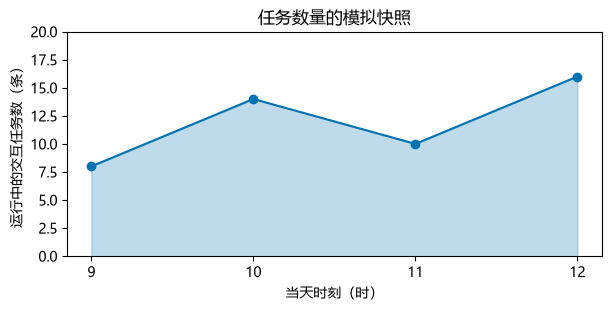

In [13]:
# 适用场景：面积图在折线下方填色，强调有序位置上的数量变化。
# 数据组织：hours 已升序排列；每个数值是该时刻运行中交互任务的模拟快照。
# 快照不是每时段完成量，不能把面积读成全天完成总数；点间连线不代表补做测量。
hours = np.array([9, 10, 11, 12])
interactive_tasks = np.array([8, 14, 10, 16])

# 最小绘制：fill_between(x, y1, y2) 填充两条边界间区域；这里 y2 固定为 0。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
# 常用参数调整：alpha=0.25 使填充半透明；叠加 plot 的观测点，set_xticks 保留实际时刻。
ax.fill_between(hours, interactive_tasks, 0, color="#0072B2", alpha=0.25)
ax.plot(hours, interactive_tasks, color="#0072B2", marker="o")
ax.set_xticks(hours)
ax.set_ylim(0, 20)
ax.set_xlabel("当天时刻（时）")
ax.set_ylabel("运行中的交互任务数（条）")
ax.set_title("任务数量的模拟快照")
# 实际成图：10 时 14 条、11 时 10 条；调整 alpha 比较填充与观测点的清晰度。
plt.show()

### 7.2 堆叠面积图显示各分量与总量

每个时刻的总数： [20 24 24 28]


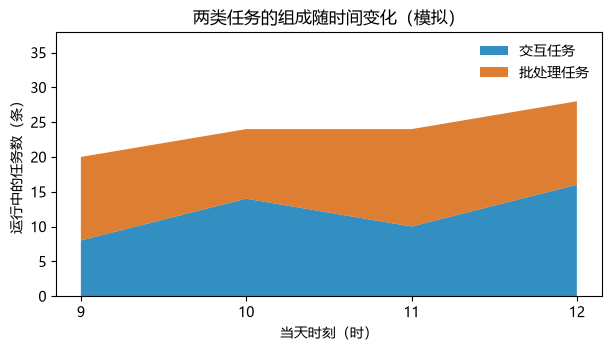

In [14]:
# 适用场景：堆叠面积图观察多个分量和总量随时间的变化。
# 数据组织：复用 hours、interactive_tasks，增加同一时刻的 batch_tasks；两类互不重叠且单位相同。
# 若要精确比较各系列自身的升降，可分别画折线；上沿升高也可能来自下面一层增加。
batch_tasks = np.array([12, 10, 14, 12])

# 最小绘制：stackplot 先接收共用横坐标，再依次接收各系列的数值。
fig, ax = plt.subplots(figsize=(6, 3.4), layout="constrained")
# 常用参数调整：baseline='zero' 从零堆叠；labels、colors 与输入系列顺序一一对应。
# alpha 调整填充不透明度，legend 展示各层名称。
ax.stackplot(
    hours,
    interactive_tasks,
    batch_tasks,
    baseline="zero",
    labels=["交互任务", "批处理任务"],
    colors=["#0072B2", "#D55E00"],
    alpha=0.8,
)
ax.set_xticks(hours)
ax.set_ylim(0, 38)
ax.set_xlabel("当天时刻（时）")
ax.set_ylabel("运行中的任务数（条）")
ax.set_title("两类任务的组成随时间变化（模拟）")
ax.legend(frameon=False)
print("每个时刻的总数：", interactive_tasks + batch_tasks)  # 预期：[20 24 24 28]。
# 实际成图：层厚是分量，上沿是总量；改变 batch_tasks 的一个值再观察对应位置。
plt.show()

## 8 坐标尺度、刻度与缺失值

### 8.1 线性尺度和对数尺度

全部为正数： True


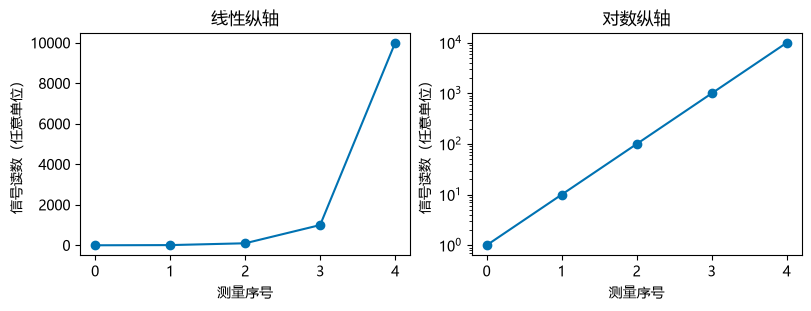

In [15]:
# 适用场景：选择坐标尺度，观察跨数量级的正值。
# 数据组织：同一组模拟信号每次扩大十倍；这只是尺度演示，不是拟合结果。
# 线性尺度的等距离对应等差，对数尺度的等距离对应等比；不要再给输入手动取对数。
# 普通 log 尺度只适用于正数；掩蔽或裁切非正值并不等于合理处理，应先解释零、负值的含义。
step = np.array([0, 1, 2, 3, 4])
signal = np.array([1, 10, 100, 1000, 10000])
print("全部为正数：", bool(np.all(signal > 0)))  # 预期：True。

# 最小绘制：两个子图都调用 plot，保留相同输入。
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, layout="constrained")
for ax in axes:
    ax.plot(step, signal, marker="o", color="#0072B2")
    ax.set_xlabel("测量序号")
    ax.set_ylabel("信号读数（任意单位）")
axes[0].set_title("线性纵轴")
# 常用参数调整：只把右图的 yscale 改为 log，刻度仍显示原始数值。
axes[1].set_yscale("log")
axes[1].set_title("对数纵轴")
# 实际成图：右图等距刻度对应相同倍数；小读数不再集中挤在底部。
plt.show()

### 8.2 刻度位置、文字与标注

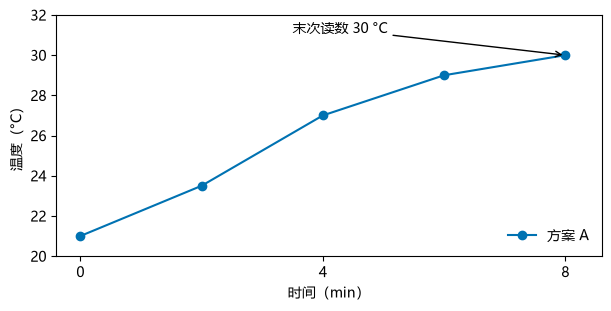

In [16]:
# 适用场景：给折线指定刻度和注释，强调一个已有观测。
# 数据组织：复用 time、temperature；标注坐标仍以 min 和 °C 为单位。
# 最小绘制：先调用 plot，得到要添加刻度和标注的曲线。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
ax.plot(time, temperature, marker="o", color="#0072B2", label="方案 A")
# 常用参数调整：set_xticks 的位置与 labels 数量一致；刻度文字不改变坐标，xlim、ylim 改变范围。
# annotate 的 xy 是箭头指向的位置，xytext 是文字位置，本例都用数据坐标；arrowprops 设置箭头。
ax.set_xticks([0, 4, 8], labels=["0", "4", "8"])
ax.set_xlim(-0.4, 8.6)
ax.set_ylim(20, 32)
ax.set_xlabel("时间（min）")
ax.set_ylabel("温度（°C）")
ax.annotate(
    "末次读数 30 °C", xy=(8, 30), xytext=(3.5, 31.1), arrowprops={"arrowstyle": "->"}
)
ax.legend(loc="lower right", frameon=False)
# 实际成图：箭头落在 (8, 30)；移动 xytext，避免文字或图例遮住数据。
plt.show()

### 8.3 缺失处断线，还是直接跨过

保留的有效观测： 4


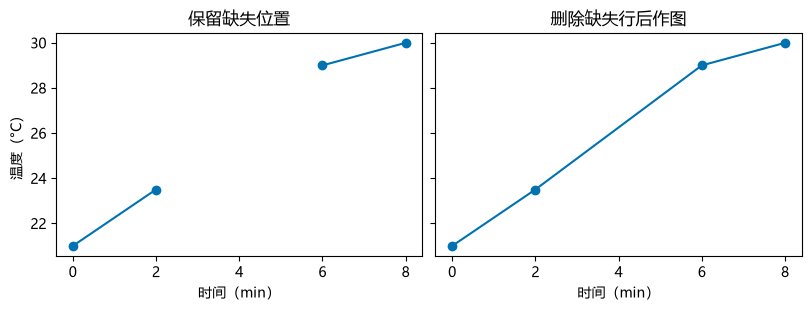

In [17]:
# 适用场景：折线图中表达一次缺失观测，而不是把它当成 0。
# 数据组织：复用 time；4 分钟温度为 NaN，valid 标记另外四个有效位置。
# NaN 或掩蔽值不画点且在该处断线；删除这一行后，剩余相邻点会直接连接。
missing_temperature = np.array([21.0, 23.5, np.nan, 29.0, 30.0])
valid = np.isfinite(missing_temperature)

# 最小绘制：左图保留 NaN，右图仅向 plot 传入有效行。
fig, axes = plt.subplots(
    1, 2, figsize=(8, 3), sharex=True, sharey=True, layout="constrained"
)
axes[0].plot(time, missing_temperature, marker="o", color="#0072B2")
axes[1].plot(time[valid], missing_temperature[valid], marker="o", color="#0072B2")
# 常用参数调整：共享坐标，固定点形和颜色，用标题区分两种缺失处理方式。
axes[0].set_title("保留缺失位置")
axes[1].set_title("删除缺失行后作图")
axes[0].set_ylabel("温度（°C）")
for ax in axes:
    ax.set_xlabel("时间（min）")
print("保留的有效观测：", int(valid.sum()))  # 预期：4；两图使用相同的有效读数。
# 实际成图：右图跨过缺失处的线不代表测得了中间过程；移动 NaN 位置再次观察。
plt.show()

## 9 误差条与误差带

### 9.1 误差条先说明统计口径

末次均值与标准差： 30.05 0.29


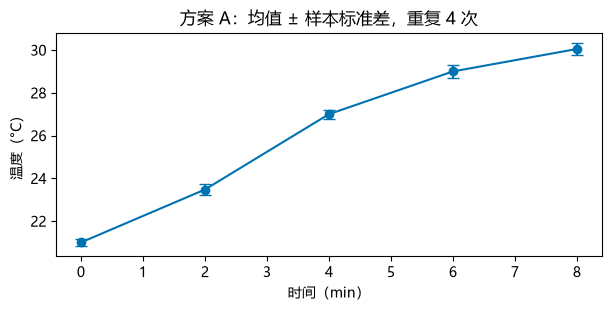

In [18]:
# 适用场景：误差条在每个位置同时展示中心值与已定义的误差范围。
# 数据组织：repeats_a 每行是一次模拟重复，每列对应 time 的一个时刻；按 axis=0 计算。
# 本例采用均值 ±1 个样本标准差，ddof=1；标准差描述读数离散程度。
# 标准误描述估计不确定性，置信区间还需相应方法与假设；本例不表示仪器精度或显著差异。
repeats_a = np.array(
    [
        [21.0, 23.5, 27.0, 29.0, 30.0],
        [20.8, 23.2, 26.7, 28.6, 29.7],
        [21.2, 23.8, 27.2, 29.3, 30.4],
        [21.0, 23.4, 27.1, 29.1, 30.1],
    ]
)
mean_a = repeats_a.mean(axis=0)
std_a = repeats_a.std(axis=0, ddof=1)

# 最小绘制：errorbar(time, mean_a, yerr=std_a) 接收中心及非负误差长度，不自动计算统计量。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
# 常用参数调整：fmt='o-' 使用圆点实线，capsize 设置端帽长度。
# 上下长度不同时，yerr 可为 (2, N) 数组：第一行下侧、第二行上侧，N 为点数；不能直接传端点。
ax.errorbar(time, mean_a, yerr=std_a, fmt="o-", capsize=4, color="#0072B2")
ax.set_xlabel("时间（min）")
ax.set_ylabel("温度（°C）")
ax.set_title("方案 A：均值 ± 样本标准差，重复 4 次")
print("末次均值与标准差：", round(mean_a[-1], 2), round(std_a[-1], 2))
# 预期：30.05 和 0.29 °C。
# 实际成图：每个时间点是四次重复的均值和标准差；标题保留重复次数与误差定义。
plt.show()

### 9.2 误差带接收区间上下界

各时间点边界有序： True


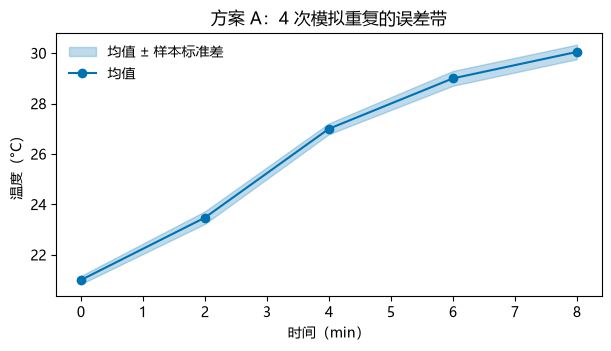

In [19]:
# 适用场景：误差带用连续色带显示一组有序位置的区间。
# 数据组织：复用 time、mean_a、std_a，计算每个时刻的下界与上界；下界不能大于上界。
# 仍表示均值 ±1 SD，连成色带不会变成置信区间，时间点之间只是直线连接。
lower_temperature = mean_a - std_a
upper_temperature = mean_a + std_a

# 最小绘制：fill_between 接收上下边界坐标，与 errorbar 的非负误差长度不同。
fig, ax = plt.subplots(figsize=(6, 3.4), layout="constrained")
# 常用参数调整：alpha=0.25 弱化色带，再用 plot 叠加均值线；label、legend 区分两者。
ax.fill_between(
    time,
    lower_temperature,
    upper_temperature,
    color="#0072B2",
    alpha=0.25,
    label="均值 ± 样本标准差",
)
ax.plot(time, mean_a, color="#0072B2", marker="o", label="均值")
ax.set_xlabel("时间（min）")
ax.set_ylabel("温度（°C）")
ax.set_title("方案 A：4 次模拟重复的误差带")
ax.legend(frameon=False)
print("各时间点边界有序：", bool(np.all(lower_temperature <= upper_temperature)))
# 预期：True。
# 实际成图：观测时刻的色带边界与上一幅误差条端点相同；只改 alpha 再比较。
plt.show()

## 10 图像与热力图

### 10.1 数值矩阵映射为颜色

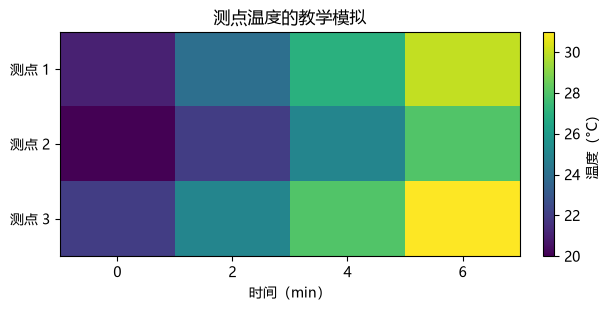

In [20]:
# 适用场景：热力图将二维数值矩阵映射为颜色。
# 数据组织：temperature_grid 的行是测点、列是时刻，每格存一次模拟温度。
# imshow 也接收 (M, N, 3) 或 (M, N, 4) 图像，M、N 分别为行列数；最后一维为 RGB/RGBA 时已是颜色。
temperature_grid = np.array(
    [
        [21, 24, 27, 30],
        [20, 22, 25, 28],
        [22, 25, 28, 31],
    ]
)

# 最小绘制：imshow(temperature_grid) 显示矩阵，保存返回对象供 colorbar 使用。
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
# 常用参数调整：cmap 选色图；origin='upper' 把第 0 行放上方，interpolation='nearest' 保留格子。
# aspect='auto' 填满绘图区，不表示真实空间比例；刻度换成时间、测点名，色条注明温度单位。
image = ax.imshow(
    temperature_grid,
    cmap="viridis",
    origin="upper",
    interpolation="nearest",
    aspect="auto",
)
ax.set_xticks([0, 1, 2, 3], labels=["0", "2", "4", "6"])
ax.set_yticks([0, 1, 2], labels=["测点 1", "测点 2", "测点 3"])
ax.set_xlabel("时间（min）")
ax.set_title("测点温度的教学模拟")
fig.colorbar(image, ax=ax, label="温度（°C）")
# 实际成图：左上格 21 °C，右下格 31 °C；改变一个矩阵元素，观察它与色条的对应。
plt.show()

### 10.2 已有 RGB 值的图像

(2, 2, 3)


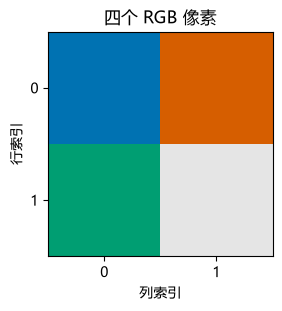

In [21]:
# 适用场景：显示像素颜色已经给定的 RGB 图像。
# 数据组织：2×2 个像素，每像素存红、绿、蓝三分量；浮点值为 0～1，整数值为 0～255。
# RGBA 还包含透明度；RGB 已指定颜色，不能添加没有数据对应关系的温度色条。
rgb = np.array(
    [
        [[0.0, 0.45, 0.70], [0.84, 0.37, 0.0]],
        [[0.0, 0.62, 0.45], [0.9, 0.9, 0.9]],
    ]
)
# 最小绘制：imshow(rgb) 直接显示颜色通道，不再使用数值色图。
fig, ax = plt.subplots(figsize=(3, 3), layout="constrained")
# 常用参数调整：nearest 保留像素边界，upper 把第 0 行放上方；刻度注明行列索引。
ax.imshow(rgb, interpolation="nearest", origin="upper")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel("列索引")
ax.set_ylabel("行索引")
ax.set_title("四个 RGB 像素")
print(rgb.shape)  # 预期：(2, 2, 3)。
# 实际成图：四格分别为蓝、橙、绿、灰；只改一个颜色分量再观察对应像素。
plt.show()

## 11 颜色归一化与可比性

### 11.1 坐标尺度和颜色尺度分开设置

坐标尺度决定点画在哪里；颜色归一化决定数值落在色图的哪个位置。改变颜色归一化不会改变格子的横纵坐标，也不会修改原数据。

| 名称 | 中文名称／含义 | 适用情形 |
| --- | --- | --- |
| Normalize | 线性颜色归一化 | 将 vmin 到 vmax 线性映射到 0 到 1 |
| LogNorm | 对数颜色归一化 | 对正数使用对数映射，观察跨数量级变化 |
| Colormap | 色图 | 将归一化位置映射为具体颜色 |
| Colorbar | 色条 | 显示数值与颜色的对应关系 |

下面同一矩阵分别采用线性和对数归一化，两者都明确设置 1 到 1000 的范围。传 norm 对象后，范围就在对象里指定，不再同时向 imshow 传 vmin、vmax。LogNorm 的上下界应为正，数据中的非正值也不能作为有效的对数颜色读数。

100 对应的位置： 0.099 0.667


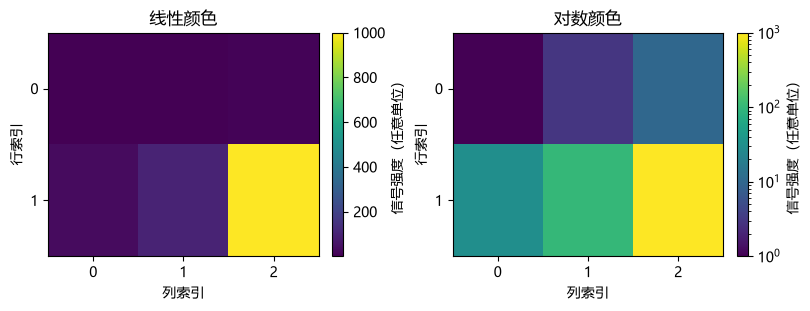

In [22]:
from matplotlib.colors import LogNorm, Normalize

# 两图复用同一个 2×3 矩阵，只改变数值到颜色的归一化方式。
intensity = np.array([[1, 3, 10], [30, 100, 1000]])
linear_norm = Normalize(vmin=1, vmax=1000)
log_norm = LogNorm(vmin=1, vmax=1000)

# 每个 Axes 分别绑定自己的 norm 和色条，坐标位置保持一致。
fig, axes = plt.subplots(1, 2, figsize=(8, 3), layout="constrained")
for ax, norm, title in zip(axes, [linear_norm, log_norm], ["线性颜色", "对数颜色"]):
    image = ax.imshow(
        intensity, norm=norm, cmap="viridis", interpolation="nearest", aspect="auto"
    )
    ax.set_title(title)
    ax.set_xlabel("列索引")
    ax.set_ylabel("行索引")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1])
    fig.colorbar(image, ax=ax, label="信号强度（任意单位）")
print(
    "100 对应的位置：",
    round(float(linear_norm(100)), 3),
    round(float(log_norm(100)), 3),
)
# 预期：0.099、0.667；数值和位置没变，颜色区别显著。
plt.show()  # 右图更容易辨认低值差异；两图色条不能互换。

### 11.2 比较多张图时统一颜色范围

0.3333333333333333


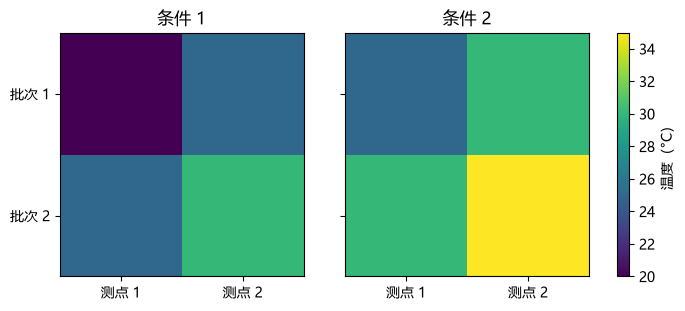

In [23]:
# 适用场景：比较同一种测量在两种条件下的热力图，要求同色同值。
# 数据组织：grid_b 在 grid_a 的每个元素上增加 5 °C，两图共用 Normalize(20, 35)。
# 各自自动归一化会让同色表示不同数值；用于比较时应统一色图、归一化方式和范围。
grid_a = np.array([[20, 25], [25, 30]])
grid_b = grid_a + 5
shared_norm = Normalize(vmin=20, vmax=35)

# 最小绘制：两次 imshow 使用同一个 shared_norm。
fig, axes = plt.subplots(
    1, 2, figsize=(7, 3), sharex=True, sharey=True, layout="constrained"
)
for ax, values, title in zip(axes, [grid_a, grid_b], ["条件 1", "条件 2"]):
    image = ax.imshow(values, cmap="viridis", norm=shared_norm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1], labels=["测点 1", "测点 2"])
    ax.set_yticks([0, 1], labels=["批次 1", "批次 2"])
# 常用参数调整：把两个 Axes 一起交给 colorbar，让它们共用一根注明单位的色条。
fig.colorbar(image, ax=axes, label="温度（°C）")
print(float(shared_norm(25)))  # 预期：约 0.333；所有 25 °C 的格子使用同一颜色。
# 实际成图：两图所有 25 °C 单元同色；只改一个矩阵中的值再核对。
plt.show()

### 11.3 顺序色图、发散色图与类别颜色

0.5


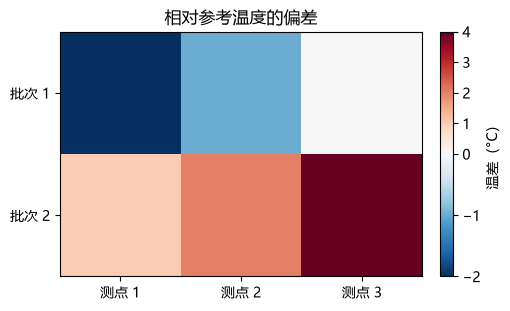

In [24]:
# 适用场景：用发散色图区分低于和高于参考值的偏差。
# 数据组织：deviation 每格是相对参考温度的温差，单位 °C，0 是有意义的中心。
# 强度等有序数值可用 viridis 顺序色图；无序类别使用离散颜色，避免暗示大小次序。
from matplotlib.colors import TwoSlopeNorm

deviation = np.array([[-2, -1, 0], [1, 2, 4]])
centered_norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=4)

# 最小绘制：imshow 接收数值矩阵，norm 决定数值对应的色图位置。
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
# 常用参数调整：TwoSlopeNorm 把 0 映射到中点，RdBu_r 在两侧使用不同色相。
# 本例范围为 −2～4 °C，两侧各占一半色图，每变化 1 °C 的色图距离不同，必须结合色条读图。
image = ax.imshow(
    deviation, cmap="RdBu_r", norm=centered_norm, interpolation="nearest", aspect="auto"
)
ax.set_xticks([0, 1, 2], labels=["测点 1", "测点 2", "测点 3"])
ax.set_yticks([0, 1], labels=["批次 1", "批次 2"])
ax.set_title("相对参考温度的偏差")
fig.colorbar(image, ax=ax, label="温差（°C）")
print(float(centered_norm(0)))  # 预期：0.5；0 映射到发散色图中点。
# 实际成图：蓝端为负、浅色接近 0、红端为正；观察负号字形和中心位置。
plt.show()

## 12 局部样式与清楚的层次

反复设置的字号和边框，可以放进局部 rc_context。离开 with 语句后，默认配置恢复；在其中创建的图保留已经设置的外观。plt.style.context 则临时应用已命名的样式，例如内置 default，避免把样式更改延续到后续单元。

下面先应用 default，再局部设置中文字体、字号和上右边框。font.size 为基本字号，axes.titlesize、axes.labelsize 分别控制标题和轴标签；它们以磅为单位。弱化网格能辅助读数，是否保留由图形目的决定。

这是一组面向屏幕阅读的课程设置，实际投稿还需按目标版面检查尺寸。样式名称或字号本身不保证图表适合论文。

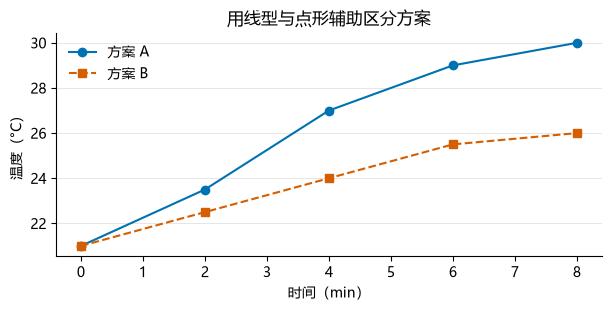

In [25]:
# 先集中列出本例需要的文字与边框设置；下方只在局部上下文中应用。
figure_style = {
    "font.family": [font_name, "sans-serif"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
}

# 退出上下文后恢复先前样式，后续图不会继承这次调整。
with plt.style.context("default"), plt.rc_context(figure_style):
    fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
    ax.plot(time, temperature, marker="o", color="#0072B2", label="方案 A")
    ax.plot(
        time, temperature_b, marker="s", linestyle="--", color="#D55E00", label="方案 B"
    )
    ax.set_xlabel("时间（min）")
    ax.set_ylabel("温度（°C）")
    ax.set_title("用线型与点形辅助区分方案")
    ax.grid(axis="y", color="0.9", linewidth=0.7)
    ax.set_axisbelow(True)  # 网格放在数据图元下方。
    ax.legend(frameon=False)
    plt.show()  # 白底、浅网格、两组同色含义与前文一致。

## 13 组合练习与图形保存

### 13.1 并列绘制散点图与误差条

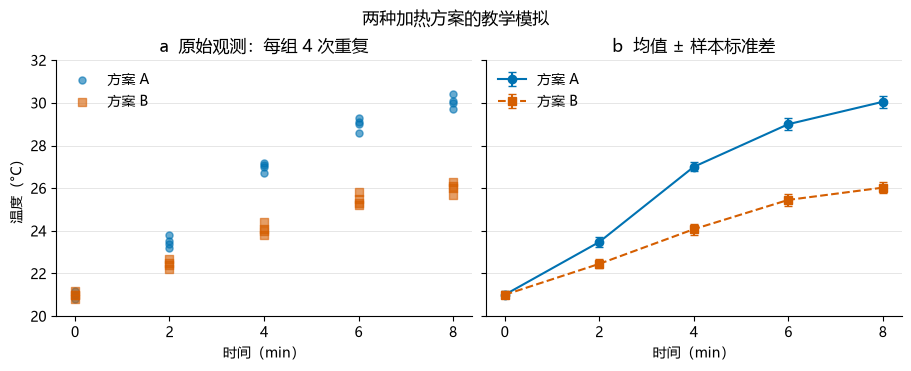

A、B 末次均值： 30.05 26.025


In [26]:
# 组合练习：把已学的散点图与误差条放在同一张图中。
# 数据组织：复用 repeats_a，并给出 repeats_b；每行一次重复，每列对应 time，共用温度范围。
# 左图保留原始读数，右图画均值 ±1 SD；均值隐藏重复轨迹，原始点也不自动给出估计不确定性。
repeats_b = np.array(
    [
        [21.0, 22.5, 24.0, 25.5, 26.0],
        [20.8, 22.2, 23.8, 25.2, 25.7],
        [21.2, 22.7, 24.4, 25.8, 26.3],
        [21.0, 22.4, 24.1, 25.3, 26.1],
    ]
)

# 最小绘制：先创建两个子图，循环中分别调用 scatter 和 errorbar。
# 常用参数调整：复用已学的颜色、点形、线型和共享坐标；调整任一组数据后重画。
with plt.style.context("default"), plt.rc_context(figure_style):
    report_fig, axes = plt.subplots(
        1, 2, figsize=(9, 3.6), sharex=True, sharey=True, layout="constrained"
    )
    for values, name, color, marker, line in [
        (repeats_a, "方案 A", "#0072B2", "o", "-"),
        (repeats_b, "方案 B", "#D55E00", "s", "--"),
    ]:
        axes[0].scatter(
            np.tile(time, len(values)),
            values.ravel(),
            s=26,
            alpha=0.6,
            color=color,
            marker=marker,
            label=name,
        )
        axes[1].errorbar(
            time,
            values.mean(axis=0),
            yerr=values.std(axis=0, ddof=1),
            color=color,
            marker=marker,
            linestyle=line,
            capsize=3,
            label=name,
        )
    axes[0].set_title("a  原始观测：每组 4 次重复")
    axes[1].set_title("b  均值 ± 样本标准差")
    axes[0].set_ylabel("温度（°C）")
    for ax in axes:
        ax.set_xlabel("时间（min）")
        ax.set_xticks(time)
        ax.set_ylim(20, 32)
        ax.grid(axis="y", color="0.9", linewidth=0.7)
        ax.set_axisbelow(True)
        ax.legend(loc="upper left", frameon=False)
    report_fig.suptitle("两种加热方案的教学模拟")
    # 实际成图：左图每组 20 个输入点，右图每组 5 个均值及对应标准差。
    plt.show()

print(
    "A、B 末次均值：",
    round(repeats_a[:, -1].mean(), 3),
    round(repeats_b[:, -1].mean(), 3),
)
# 预期：30.05、26.025 °C；这只是给定模拟数据的汇总。

### 13.2 保存 PNG 与 SVG

Figure.savefig 根据扩展名选择格式。PNG 是位图；保持图幅不变时，提高 dpi 会增加像素数。当前图幅为 9 × 3.6 英寸，按 200 dpi 保存且不额外裁切时，对应 1800 × 720 像素。SVG 可保留线条等矢量元素，但图像或被栅格化的图元仍可能是位图。

bbox_inches="tight" 可以按内容收紧边界，也会改变输出边界与像素尺寸；本例已有 constrained 布局，因此不启用额外裁切。保存时明确引用 report_fig，避免把另一张当前图误保存。

下面用 tempfile.mkdtemp 建立临时输出目录，保存后保持文件可读。打开打印的目录，分别查看 PNG 和 SVG：核对文字和单位、误差条、图例、留白及边缘裁切；还应把图缩放到实际使用尺寸检查可读性。plt.close 关闭图形对象，不会删除文件。

In [27]:
import tempfile
from pathlib import Path

output_dir = Path(tempfile.mkdtemp(prefix="matplotlib-ch01-"))
png_path = output_dir / "temperature-report.png"
svg_path = output_dir / "temperature-report.svg"

report_fig.savefig(png_path, dpi=200, facecolor="white")
report_fig.savefig(svg_path, facecolor="white")
plt.close(report_fig)
print("输出目录：", output_dir)
print(png_path.name, png_path.exists(), svg_path.name, svg_path.exists())
# 两个 exists() 都应为 True；这只说明文件存在，成图仍需实际打开查看。

输出目录： C:\Users\ZHUANG\AppData\Local\Temp\matplotlib-ch01-5zo9whi1
temperature-report.png True temperature-report.svg True


### 13.3 查看后清理

完成图片查看后，把 cleanup 改为 True 再运行本单元。它只删除本次创建的两个文件，再移除空目录；若目录中另存了文件，rmdir 会拒绝删除非空目录。不要在查看前清理。

In [28]:
cleanup = False
if cleanup:
    png_path.unlink(missing_ok=True)
    svg_path.unlink(missing_ok=True)
    output_dir.rmdir()
    print("已清理本次导出文件。")  # 预期：仅在 cleanup=True 且删除完成时显示此提示。
else:
    print("保留导出文件，请先完成查看。")  # 预期：默认 cleanup=False，显示此提示并保留文件。

保留导出文件，请先完成查看。


## 本章小结

（1）Figure 管整张图，Axes 放数据，Axis 管单条坐标轴。显式操作对象后，多图与导出目标更容易辨认。

（2）条形图比较数值，分组柱方便比较对应系列，堆叠柱同时表达组成与总量。饼图与环形图需要一个完整且不重复计数的整体，百分比也需要说明分母。

（3）折线与面积图按有序横坐标展示变化；堆叠面积图的层厚表示分量，上沿表示累计值。散点图显示成对观测，直方图按区间统计数值；它们回答的问题不同。

（4）坐标尺度改变位置，颜色归一化改变颜色。对数映射有正值条件；多图比较要核对坐标范围及同色是否同值。

（5）缺失、重叠、分箱和汇总都会影响可见信息。误差条接收误差长度，误差带接收边界坐标；两者都要说明统计口径。

（6）保存成功后仍要实际查看导出文件。图幅、分辨率、字体和布局共同决定图表在最终尺寸下是否清楚。

自查：能否说清一个点、一个扇区或一层面积代表什么，分母与误差从哪里来，以及哪些信息没有画出来？

## 练习

（1）改变图形，解释保留的信息

下面是四个时刻的单次模拟温度。分别画折线图和散点图，加上时间与温度单位；再用一句话说明两种图分别突出什么，以及折线连接不能证明什么。

可验证标准：两图都保留四个输入坐标，横轴顺序为 0、1、3、6 分钟；图形解释区分观测点与点间连线。

In [29]:
exercise_time = np.array([0, 1, 3, 6])
exercise_temperature = np.array([20, 22, 26, 27])
# 在这里创建 Figure、Axes，分别绘图并调用 plt.show()。
# 在这里用 print() 写出图形突出与隐藏的信息。

（2）统一颜色后再比较

把两个模拟温度矩阵并列画成热力图，使用相同的 Normalize、viridis 色图和一根带单位的色条。然后尝试分别自动归一化，比较它们给人的印象，并说明哪一种适合跨条件比较。

可验证标准：统一范围覆盖 18 到 28 °C；两个矩阵中的 22 °C 颜色完全一致；解释中指出“各自颜色相同”不一定表示温度相同。

In [30]:
exercise_grid_a = np.array([[18, 20], [22, 24]])
exercise_grid_b = np.array([[22, 24], [26, 28]])
# 在这里建立共享 Normalize，绘制两图并添加带单位的色条。
# 再比较各自自动归一化，说明适用的比较目的。

（3）选择误差定义并导出

下面每行是同一条件的一次模拟重复，每列对应 0、2、4 分钟。计算各列均值与样本标准差，画误差条；标题说明重复次数及误差定义。将图保存在自己创建的临时目录，分别导出 PNG 和 SVG，查看后再清理。

可验证标准：三列均值为 20、23、26 °C，样本标准差均为 1 °C；两种格式的中文、单位、误差条和边缘完整。说明这张汇总图没有直接展示哪条原始重复轨迹。

In [31]:
exercise_repeats = np.array([[19, 22, 25], [20, 23, 26], [21, 24, 27]])
exercise_times = np.array([0, 2, 4])
# 在这里计算均值和 ddof=1 的标准差，画图并标明统计口径。
# 在这里导出、实际查看并清理自己创建的临时文件。

（4）为组成与比较选择图形

下面是一天内收到的四类模拟任务，每条只属于一个类别。先画带类别名与百分比的环形图，再画按次数降序排列的水平条形图；说明哪幅图突出部分与整体，哪幅图更方便比较接近的次数。

把全部次数乘以 2，再画一次环形图，比较扇区比例与总数。随后考虑“同一条任务可以归入多个类别”的条件：说明此时为什么不能把这四类次数直接解释为任务总数的组成。

可验证标准：原始总数为 80 条，四类占比分别为 30%、27.5%、25%、17.5%；翻倍后总数为 160 条，扇区比例不变。两种图保留相同类别与次数对应关系，解释中指出单看扇区比例看不出总量翻倍。

In [32]:
exercise_categories = np.array(["模型推理", "数据清洗", "报表生成", "文件归档"])
exercise_counts = np.array([24, 22, 20, 14])
# 在这里分别创建环形图和排序条形图，核对类别、百分比与总量。
# 再将次数翻倍，观察环形图比例，并用 print() 解释图形选择及重复计数的影响。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：比较相同温度时，先检查它在两张图中被归一化到什么位置。

提示 2：统一色图还不够；归一化的上下限也要一致。

### 练习（2）参考解析

共享 Normalize(vmin=18, vmax=28) 时，22 °C 在两图中都映射到 $(22-18)/(28-18)=0.4$，再由同一 viridis 色图得到同一种颜色。

分别自动归一化时，A 的范围为 18～24 °C，B 为 22～28 °C；22 °C 分别映射到 2/3 和 0。反过来，两图最深端的同一种颜色可能分别表示 18、22 °C。跨条件比较绝对温度应共享范围；分别归一化可以突出各图内部变化，但需要明确各自色条，不能据同色判断数值相等。

## 参考与引用来源

本章新增示意图由 CMYK Labs 原创，依据下表对应概念与本章教学输入绘制；示意图不作为实际运行截图或数学证明。

原有来源于 2026-09-21 核查；新增图形及选择原则的来源于 2026-09-22 核查。知识解释采用中文转述，代码与教学模拟数据为本章编写；示例网站用于继续查找图形表达方式，不替代 API 依据。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Matplotlib 3.11.2 官方文档 | 第 1～3 节：[Quick start guide 的 A simple example、Parts of a Figure 与显式接口](https://matplotlib.org/stable/users/explain/quick_start.html)、[subplots 的 sharex、sharey、squeeze](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)、[Constrained layout guide](https://matplotlib.org/stable/users/explain/axes/constrainedlayout_guide.html)。第 2、12 节：[Text with non-latin glyphs](https://matplotlib.org/stable/users/explain/text/text_props.html#text-with-non-latin-glyphs)、[font_manager.findfont](https://matplotlib.org/stable/api/font_manager_api.html#matplotlib.font_manager.findfont)、[rcParams、Temporary rc settings 与 style sheets](https://matplotlib.org/stable/users/explain/customizing.html)。第 4、8～9 节：[scatter 的 s、alpha 等参数](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)、[bar 的 height 与 bottom](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)、[hist 的 bins 与 density](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)、[LogScale 的正值范围及 nonpositive](https://matplotlib.org/stable/api/scale_api.html#matplotlib.scale.LogScale)、[annotate 的 xy 与 xytext](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html)、[Plotting masked and NaN values](https://matplotlib.org/stable/gallery/lines_bars_and_markers/masked_demo.html)、[errorbar 的 yerr 与 capsize](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html)。第 10～11 节：[imshow 的 X、origin、aspect、interpolation、norm](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html)、[Colormap normalization 的线性、Logarithmic 与 TwoSlopeNorm](https://matplotlib.org/stable/users/explain/colors/colormapnorms.html)、[Choosing Colormaps 的 Sequential、Diverging 与 Qualitative](https://matplotlib.org/stable/users/explain/colors/colormaps.html)。第 13 节：[Figure.savefig 的格式、dpi 与 bbox_inches](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html)、[close](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html)。第 5 节：[barh 的 y、width 与类别重复条件](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.barh.html)、[水平条形图与坐标方向示例](https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html)、[bar 的 x、width、bottom、align](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)、[堆叠柱示例](https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html)。第 6 节：[pie 的 normalize、labels、autopct、startangle、counterclock、pctdistance 与 wedgeprops](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pie.html)、[饼图标签与百分比示例](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html)、[Nested pie charts 的 width 与圆环示例](https://matplotlib.org/stable/gallery/pie_and_polar_charts/nested_pie.html)。第 7、9 节：[fill_between 的 x、y1、y2 与直接连接规则](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)、[stackplot 的系列输入、zero 基线、labels 和 colors（页面版本 3.11.1，本章执行 3.11.2）](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stackplot.html)。继续查阅：[官方示例图库](https://matplotlib.org/stable/gallery/index.html)，其中本章实际参考的缺失值示例已单独定位。 |
| NumPy 2.5 官方文档 | 第 5 节：[numpy.argsort 的排序索引和一维索引示例](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)。第 9、13 节：[numpy.std 的 axis、ddof 及 Notes](https://numpy.org/doc/stable/reference/generated/numpy.std.html)，核对按列计算和样本标准差的分母约定。 |
| Seaborn 0.13.2 官方教程 | 第 9、13 节：[Statistical estimation and error bars](https://seaborn.pydata.org/tutorial/error_bars.html)，区分数据离散程度与估计不确定性；本章用 Matplotlib 接收已计算的误差长度，不调用 Seaborn。 |
| Python 3.12 官方文档 | 第 13 节：[tempfile.mkdtemp](https://docs.python.org/3.12/library/tempfile.html#tempfile.mkdtemp)、[Path.unlink](https://docs.python.org/3.12/library/pathlib.html#pathlib.Path.unlink)、[Path.rmdir](https://docs.python.org/3.12/library/pathlib.html#pathlib.Path.rmdir)，临时目录创建与显式清理。 |
| Nature research figure guide | 第 12～13 节：[Building and exporting figure panels 的 Panel arrangement、Fonts、Accessibility](https://research-figure-guide.nature.com/figures/building-and-exporting-figure-panels/)，参考布局、文字与非单一颜色编码的表达原则；本章图幅与字号是课程选择。 |
| Python Graph Gallery | [Matplotlib 专题入口](https://python-graph-gallery.com/matplotlib/)，供按图形类别查找表达与样式示例；本章未复制或改编该站具体示例。 |
| ONS Service manual | 第 5～6 节：[Bar chart 的零基线和类别排序](https://service-manual.ons.gov.uk/data-visualisation/chart-types/bar-charts)、[Stacked bar charts 的整体组成、共同基线和数据类型条件](https://service-manual.ons.gov.uk/data-visualisation/chart-types/stacked-bar-charts)、[Pie and doughnut charts 的使用条件、多个分布比较和标签](https://service-manual.ons.gov.uk/data-visualisation/chart-types/pie-and-doughnut-charts)。参考图形选择原则，不照搬该机构的配色和尺寸。 |